In [7]:
import pandas as pd
import matplotlib.pyplot as plt

arquivo = "data_RS.xlsx"

jaguarao = pd.read_excel(arquivo, sheet_name="(URF) 1010252 - JAGUARAO")

bage = pd.read_excel(arquivo, sheet_name="(URF) 1010253 - BAGE")

santana_do_livramento = pd.read_excel(arquivo, sheet_name="(URF) 1010351 - IRF SANTANA DO ")

uruguaiana = pd.read_excel(arquivo, sheet_name="(URF) 1010900 - URUGUAIANA")

sao_borja = pd.read_excel(arquivo, sheet_name="(URF) 1010953 - SAO BORJA")

chui = pd.read_excel(arquivo, sheet_name="(URF) 1015500 - CHUI")

santana_do_livramento2 = pd.read_excel(arquivo, sheet_name="(URF) 1015600 - SANTANA DO LIVR")

uruguaiana2 = pd.read_excel(arquivo, sheet_name="(URF) 1017500 - ALF - URUGUAIAN")

sao_borja2 = pd.read_excel(arquivo, sheet_name="(URF) 1017503 - IRF - SÃO BORJA")

aeroporto_salgado = pd.read_excel(arquivo, sheet_name="(URF) 1017600 - AEROPORTO SALGA")

chui2 = pd.read_excel(arquivo, sheet_name="(URF) 1017701 - IRF - CHUÍ")

rio_grande = pd.read_excel(arquivo, sheet_name="(URF) 1017700 - PORTO DE RIO GR")

porto_alegre = pd.read_excel(arquivo, sheet_name="(URF) 1017800 - ALF - PORTO ALE")

aeroporto_salgado2 = pd.read_excel(arquivo, sheet_name="(URF) 1017801 - IRF - AEROPORTO")

santana_do_livramento3 = pd.read_excel(arquivo, sheet_name="(URF) 1017900 - ALF - SANTANA D")

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re

arquivo = "data_RS.xlsx"
abas = pd.read_excel(arquivo, sheet_name=None)

nomes_portos = {
    "1010252": "1010252 - Jaguarão",
    "1010253": "1010253 - Bagé",
    "1010351": "1010351 - IRF Santana do Livramento",
    "1010900": "1010900 - Uruguaiana",
    "1010953": "1010953 - São Borja",
    "1015500": "1015500 - Chuí",
    "1015600": "1015600 - Santana do Livramento",
    "1017500": "1017500 - ALF Uruguaiana",
    "1017503": "1017503 - IRF São Borja",
    "1017600": "1017600 - Aeroporto Salgado Filho",
    "1017700": "1017700 - Porto de Rio Grande",
    "1017701": "1017701 - IRF Chuí",
    "1017800": "1017800 - ALF Porto Alegre",
    "1017801": "1017801 - IRF Aeroporto Salgado Filho",
    "1017900": "1017900 - ALF Santana do Livramento"
}

lista_dfs = []

for nome_aba, df in abas.items():
    df = df.copy()

    codigo_match = re.search(r"\d{7}", nome_aba)
    if codigo_match:
        codigo = codigo_match.group()
        df["Porto_URF"] = nomes_portos.get(codigo, f"{codigo} - Nome não mapeado")
        lista_dfs.append(df)

base = pd.concat(lista_dfs, ignore_index=True)

base["Peso_KG"] = pd.to_numeric(base["Peso_KG"], errors="coerce")
base["Ano"] = pd.to_numeric(base["Ano"], errors="coerce")

base = base.dropna(subset=["Porto_URF", "Ano", "Peso_KG"])
base["Ano"] = base["Ano"].astype(int)

In [9]:
df_porto_ano = (
    base.groupby(["Porto_URF", "Ano"], as_index=False)["Peso_KG"]
    .sum()
)

df_porto_ano["Peso_milhoes"] = df_porto_ano["Peso_KG"] / 1_000_000

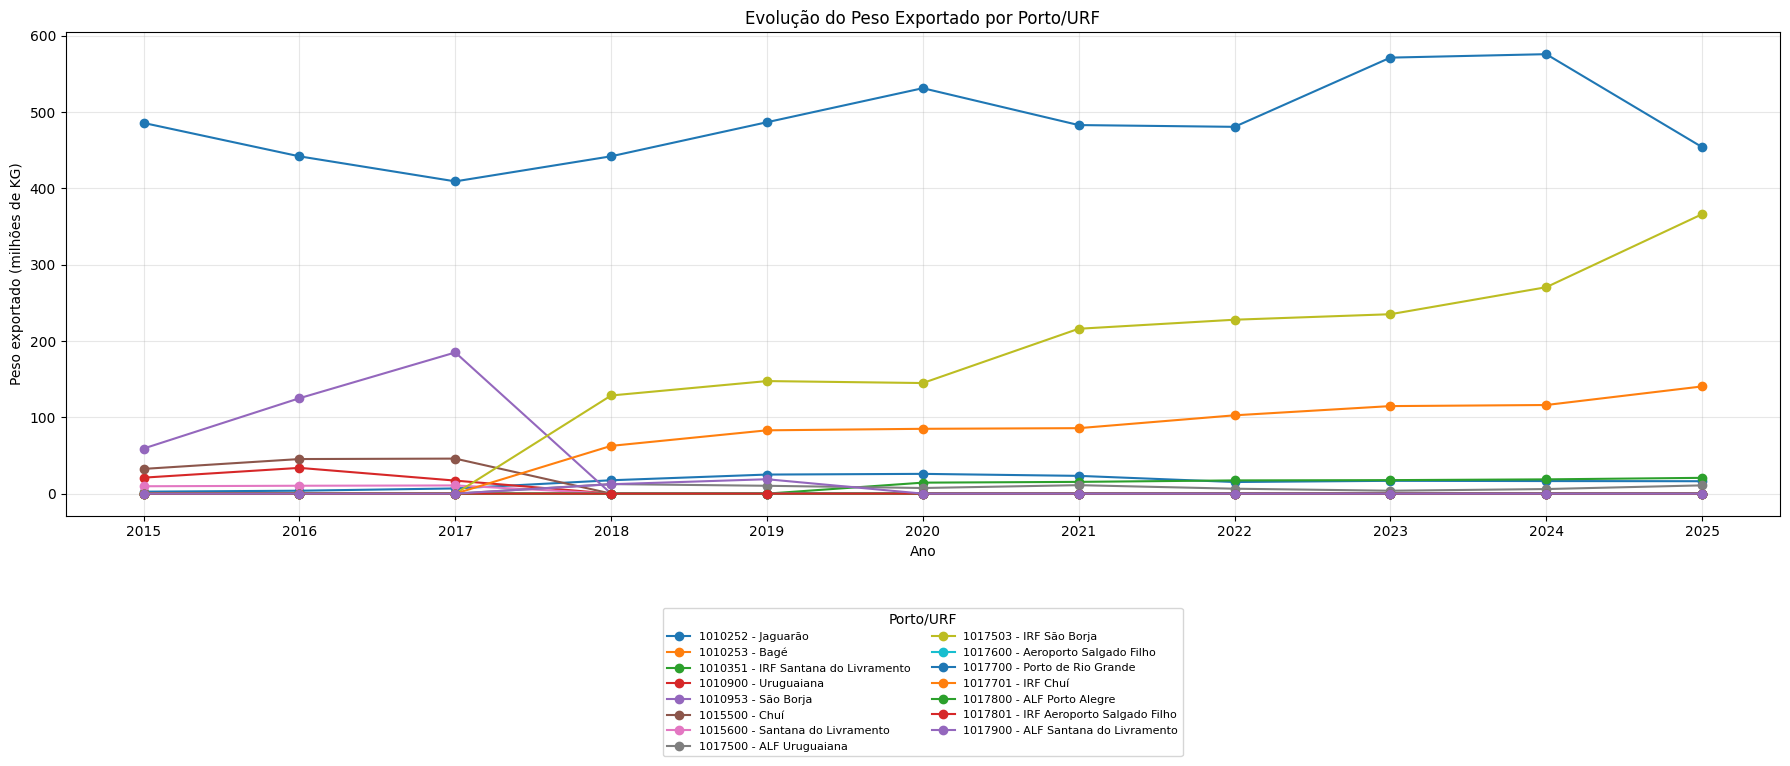

In [10]:
grafico = df_porto_ano.copy()

tabela_grafico = grafico.pivot(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes"
).fillna(0)

plt.figure(figsize=(18, 8))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        label=porto
    )

plt.title("Evolução do Peso Exportado por Porto/URF")
plt.xlabel("Ano")
plt.ylabel("Peso exportado (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

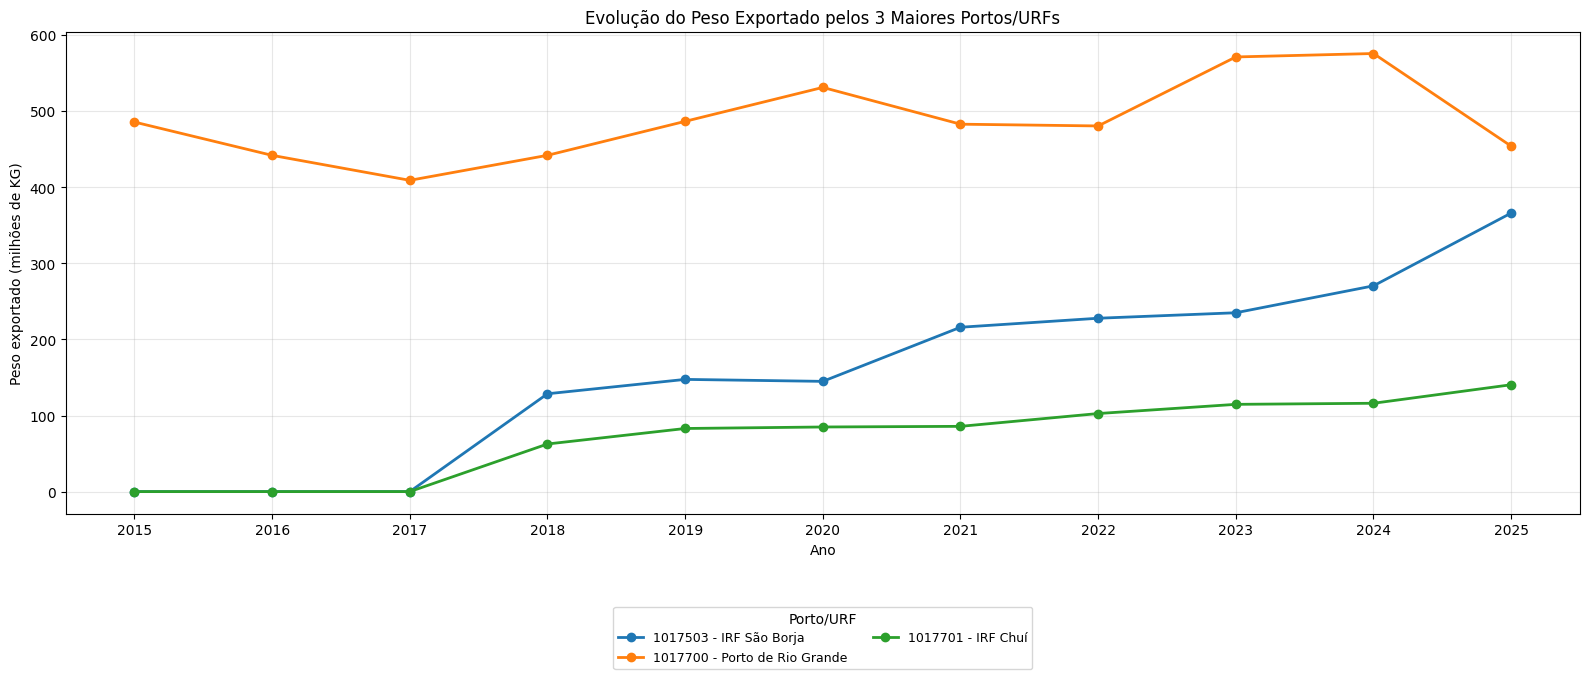

In [11]:
grafico = df_porto_ano.copy()

# Identificar os 3 maiores exportadores no total do período
top3_portos = (
    grafico
    .groupby("Porto_URF")["Peso_milhoes"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# Filtrar apenas o Top 5
grafico_top3 = grafico[grafico["Porto_URF"].isin(top3_portos)]

# Criar tabela para o gráfico
tabela_grafico = grafico_top3.pivot_table(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 7))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        linewidth=2,
        label=porto
    )

plt.title("Evolução do Peso Exportado pelos 3 Maiores Portos/URFs")
plt.xlabel("Ano")
plt.ylabel("Peso exportado (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=9
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()